# Loading Libraries and Packages

In [1]:
import os, random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Loading Images

In [2]:
def load_images(img1_path, img2_path):
    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)

    if img1 is None or img2 is None:
        raise ValueError("Error loading images")

    return img1, img2

# Extracting and Matching Features (SIFT Features)

In [3]:
def compute_sift_features(img1, img2):
    """
    Compute SIFT keypoints and descriptors
    """
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    sift = cv2.SIFT_create()

    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    return kp1, des1, kp2, des2


def match_features(des1, des2, ratio_thresh=0.75):
    """
    KNN matching + Lowe's ratio test
    """
    bf = cv2.BFMatcher()

    matches = bf.knnMatch(des1, des2, k=2)

    good_matches = []
    for m, n in matches:
        if m.distance < ratio_thresh * n.distance:
            good_matches.append(m)

    return good_matches

def get_matched_points(kp1, kp2, matches):
    pts1 = np.array([kp1[m.queryIdx].pt for m in matches])
    pts2 = np.array([kp2[m.trainIdx].pt for m in matches])

    return pts1, pts2

## Visualizing Matches

In [4]:
def select_spatially_distributed_matches(kp1, matches, img_shape,
                                         grid_size=(6, 8),
                                         max_matches=50):
    """
    Select matches uniformly across image using grid sampling
    """

    h, w = img_shape[:2]
    grid_h, grid_w = grid_size

    cell_h = h / grid_h
    cell_w = w / grid_w

    # Assign matches to grid cells
    grid = {}

    for m in matches:
        x, y = kp1[m.queryIdx].pt

        i = int(y // cell_h)
        j = int(x // cell_w)

        key = (i, j)

        if key not in grid:
            grid[key] = []

        grid[key].append(m)

    # Sample uniformly from each cell
    selected = []

    per_cell = max(1, max_matches // (grid_h * grid_w))

    for cell_matches in grid.values():
        np.random.shuffle(cell_matches)
        selected.extend(cell_matches[:per_cell])

    # If still less, fill randomly
    if len(selected) < max_matches:
        remaining = list(set(matches) - set(selected))
        np.random.shuffle(remaining)
        selected.extend(remaining[:max_matches - len(selected)])

    return selected[:max_matches]

In [200]:
def visualize_matches_spatial(
    img1, img2, kp1, kp2, matches,
    max_matches=50,
    grid_size=(6, 8),
    save_path=None
):
    """
    Robust spatial match visualization (handles different image sizes)
    """

    # --- Select distributed matches ---
    selected_matches = select_spatially_distributed_matches(
        kp1, matches, img1.shape,
        grid_size=grid_size,
        max_matches=max_matches
    )

    # --- Convert to RGB ---
    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

    # --- Resize to same height ---
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    target_h = max(h1, h2)

    scale1 = target_h / h1
    scale2 = target_h / h2

    img1_resized = cv2.resize(img1, (int(w1 * scale1), target_h))
    img2_resized = cv2.resize(img2, (int(w2 * scale2), target_h))

    h, w1_new = img1_resized.shape[:2]
    _, w2_new = img2_resized.shape[:2]

    # --- Create canvas (no padding artifacts) ---
    canvas = np.hstack((img1_resized, img2_resized))

    plt.figure(figsize=(14, 6))
    plt.imshow(canvas)
    plt.axis("off")

    # --- Draw matches ---
    for m in selected_matches:
        x1, y1 = kp1[m.queryIdx].pt
        x2, y2 = kp2[m.trainIdx].pt

        # --- Scale coordinates ---
        x1 *= scale1
        y1 *= scale1
        x2 *= scale2
        y2 *= scale2

        # --- Soft random color ---
        color = np.random.uniform(0.2, 0.8, size=3)

        # Line
        plt.plot([x1, x2 + w1_new], [y1, y2],
                 color=color, linewidth=0.8, alpha=0.9)

        # Points (more visible)
        plt.scatter(x1, y1, s=30, c=[color], edgecolors='white', linewidths=0.6)
        plt.scatter(x2 + w1_new, y2, s=30, c=[color], edgecolors='white', linewidths=0.6)

    plt.title(
        f"Image1: {len(kp1)} kp | Image2: {len(kp2)} kp\n"
        f"Showing {len(selected_matches)} / {len(matches)} matches"
    )

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

In [13]:
def visualize_matches_spatial(
    img1, img2, kp1, kp2, matches,
    max_matches=50,
    grid_size=(6, 8),
    save_path=None
):
    """
    Spatially distributed match visualization
    """

    # --- Select distributed matches ---
    selected_matches = select_spatially_distributed_matches(
        kp1, matches, img1.shape,
        grid_size=grid_size,
        max_matches=max_matches
    )

    img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

    h1, w1, _ = img1_rgb.shape
    h2, w2, _ = img2_rgb.shape

    canvas = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8)
    canvas[:h1, :w1] = img1_rgb
    canvas[:h2, w1:w1 + w2] = img2_rgb

    plt.figure(figsize=(14, 7))
    plt.imshow(canvas)
    plt.axis("off")

    for m in selected_matches:
        x1, y1 = kp1[m.queryIdx].pt
        x2, y2 = kp2[m.trainIdx].pt
    
        # --- Generate soft random color ---
        color = np.random.uniform(0.1, 0.9, size=3)  # avoids too bright/dark colors
    
        # Line
        plt.plot([x1, x2 + w1], [y1, y2],
                 color=color, linewidth=1)
    
        # Points (highlighted but subtle)
        plt.scatter(x1, y1, s=20, c=[color], edgecolors='white', linewidths=0.5)
        plt.scatter(x2 + w1, y2, s=20, c=[color], edgecolors='white', linewidths=0.5)

    plt.title(f"Image 1 : {len(kp1)} keypoints\nImage 2 : {len(kp2)} keypoints\nDisplaying {len(selected_matches)} (out of {len(matches)} Matches)")

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved distributed matches to: {save_path}")

    plt.show()

# Loading Image Pairs (Image ID and Path)

In [167]:
df_images = pd.read_csv("../camera_data.csv")
df_pairs = pd.read_csv("../best_image_pairs3.csv")

In [168]:
# df_pairs[df_pairs["baseline"] >= 1].sort_values(by = "overlap", ascending = False)[:10]
# print(df_pairs[6:50].sort_values(by = "overlap", ascending = False))
df_pairs.head(10)

,img1_id,img2_id,overlap,baseline,angle,score
0,225,231,3434,0.839300,11.213439,0.647580
1,225,232,3793,0.843088,5.652869,0.638692
2,226,232,3219,0.840993,13.759098,0.631209
3,99,105,3703,0.608581,6.266322,0.627549
4,226,233,3405,0.840751,8.872413,0.623349
5,224,231,3770,0.842938,4.371209,0.620089
6,86,87,332,0.003581,27.908232,NaN
7,97,98,2599,0.016004,26.530615,NaN
8,160,170,418,0.017117,28.648559,NaN
9,31,33,864,0.018055,32.619004,NaN


In [10]:
image_base_path = "/Users/arjunmallick/Reconstruction_Projects/Main-Building-Dense-2/Images"
image_pairs = []
image_id_pairs = []

print("#"*15," Best Image Pairs ","#"*15)
for idx, row in df_pairs.iterrows():
        i = row["img1_id"]
        j = row["img2_id"]

        img1_row = df_images[df_images.image_id == i].iloc[0]
        img2_row = df_images[df_images.image_id == j].iloc[0]

        print(f"{img1_row.image_name} ↔ {img2_row.image_name}")

        path1 = os.path.join(image_base_path,img1_row.image_name)
        path2 = os.path.join(image_base_path,img2_row.image_name)

        image_pairs.append((path1, path2))
        image_id_pairs.append((int(i),int(j)))

###############  Best Image Pairs  ###############
VID_20260224_155739_4.jpg ↔ VID_20260224_155831_1.jpg
VID_20260224_155739_4.jpg ↔ VID_20260224_155831_2.jpg
VID_20260224_155739_5.jpg ↔ VID_20260224_155831_2.jpg
IMG_20260224_154558.jpg ↔ IMG_20260224_154700.jpg
VID_20260224_155739_5.jpg ↔ VID_20260224_155831_3.jpg
VID_20260224_155739_3.jpg ↔ VID_20260224_155831_1.jpg
IMG_20260224_154434.jpg ↔ IMG_20260224_154436.jpg
IMG_20260224_154548.jpg ↔ IMG_20260224_154550.jpg
VID_20260224_155425_10.jpg ↔ VID_20260224_155425_6.jpg
IMG_20260224_153757.jpg ↔ IMG_20260224_153803.jpg
VID_20260224_155831_0.jpg ↔ VID_20260224_155831_3.jpg
IMG_20260224_153801.jpg ↔ IMG_20260224_153803.jpg
IMG_20260224_154438.jpg ↔ IMG_20260224_154452.jpg
IMG_20260224_153501.jpg ↔ IMG_20260224_153507.jpg
VID_20260224_155739_5.jpg ↔ VID_20260224_155739_7.jpg
VID_20260224_155330_2.jpg ↔ VID_20260224_155330_6.jpg
IMG_20260224_154436.jpg ↔ IMG_20260224_154444.jpg
IMG_20260224_153523.jpg ↔ IMG_20260224_153526.jpg
IMG_20260224

# Driver Code (For Feature Extraction and Matching)



Evaluating Pair: 95 ↔ 232
Keypoints Image1: 42685
Keypoints Image2: 14309
Good matches (after ratio test): 815


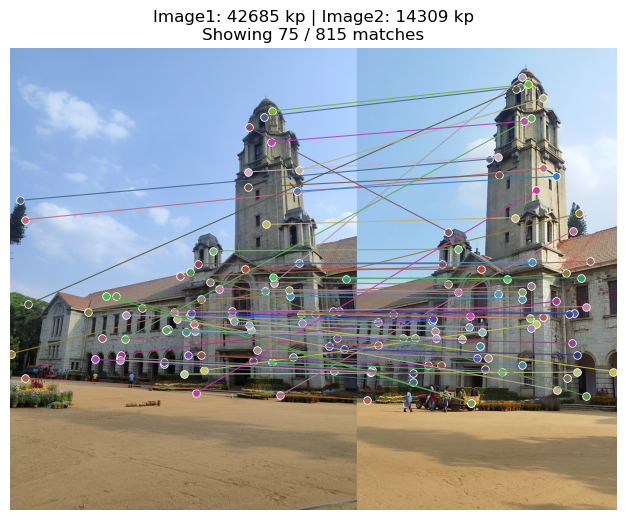

In [202]:
# Image Path and ID
## Important Indices (Rotation Only) = 7, 11, 23, 36,
# 7 --- 97	98
# 36 --- 113      115
# 23 -- 6 --- 7
## Important Indices (Rotation Only) = 63,

index = 5
id1 = image_id_pairs[index][0]
id2 = image_id_pairs[index][1]
img1_path = image_pairs[index][0]
img2_path = image_pairs[index][1]

print(f"\n\nEvaluating Pair: {id1} ↔ {id2}")

# 1. Load images
img1, img2 = load_images(img1_path, img2_path)

# 2. SIFT features
kp1, des1, kp2, des2 = compute_sift_features(img1, img2)

print(f"Keypoints Image1: {len(kp1)}")
print(f"Keypoints Image2: {len(kp2)}")

# 3. Matching
matches = match_features(des1, des2)

print(f"Good matches (after ratio test): {len(matches)}")

# 4. Extract matched points
pts1, pts2 = get_matched_points(kp1, kp2, matches)

# 5. Visualization
# visualize_matches(img1, img2, kp1, kp2, matches, max_matches=50)

visualize_matches_spatial(img1, img2, kp1, kp2, matches, max_matches=75,grid_size=(6, 8),
    save_path="../Report/distributed_matches_10.png")

# Fundamental Matrix Evaluation

## Normalize Points

In [20]:
def normalize_points(pts):
    """
    Normalize points so that:
    - centroid = (0,0)
    - avg distance = sqrt(2)
    """
    mean = np.mean(pts, axis=0)
    std = np.std(pts)

    scale = np.sqrt(2) / std

    T = np.array([
        [scale, 0, -scale * mean[0]],
        [0, scale, -scale * mean[1]],
        [0, 0, 1]
    ])

    pts_h = np.hstack([pts, np.ones((pts.shape[0], 1))])
    pts_norm = (T @ pts_h.T).T

    return pts_norm[:, :2], T

## 8-point Algorithm 

In [21]:
def build_matrix_A(pts1, pts2):
    A = []

    for (x, y), (xp, yp) in zip(pts1, pts2):
        A.append([
            xp*x, xp*y, xp,
            yp*x, yp*y, yp,
            x, y, 1
        ])

    return np.array(A)

    
def compute_F_eight_point(pts1, pts2):
    # Step 1: Normalize
    pts1_norm, T1 = normalize_points(pts1)
    pts2_norm, T2 = normalize_points(pts2)

    # Step 2: Build A
    A = build_matrix_A(pts1_norm, pts2_norm)

    # Step 3: Solve Af = 0 using SVD
    U, S, Vt = np.linalg.svd(A)
    F = Vt[-1].reshape(3, 3)

    # Step 4: Enforce rank-2 constraint
    U, S, Vt = np.linalg.svd(F)
    S[2] = 0
    F_rank2 = U @ np.diag(S) @ Vt

    # Step 5: Denormalize
    F_final = T2.T @ F_rank2 @ T1

    return F_final

## RANSAC implementation for 8-Point Algorithm (with Sampson error)

In [22]:
def sampson_error(F, pts1, pts2):
    pts1_h = np.hstack([pts1, np.ones((pts1.shape[0],1))])
    pts2_h = np.hstack([pts2, np.ones((pts2.shape[0],1))])

    Fx1 = F @ pts1_h.T
    Ftx2 = F.T @ pts2_h.T

    denom = Fx1[0]**2 + Fx1[1]**2 + Ftx2[0]**2 + Ftx2[1]**2

    err = (np.sum(pts2_h * (F @ pts1_h.T).T, axis=1)**2) / denom

    return err
    
def ransac_fundamental(pts1, pts2, num_iters=2000, threshold=1e-3):
    best_F = None
    best_inliers = []
    max_inliers = 0

    N = pts1.shape[0]

    for _ in range(num_iters):
        # Random sample of 8 points
        idx = random.sample(range(N), 8)

        sample_pts1 = pts1[idx]
        sample_pts2 = pts2[idx]

        try: 
            F = compute_F_eight_point(sample_pts1, sample_pts2)
        # Handle degenerate cases, like collinear points
        except: 
            continue

        errors = sampson_error(F, pts1, pts2)
        inliers = errors < threshold

        num_inliers = np.sum(inliers)

        if num_inliers > max_inliers:
            max_inliers = num_inliers
            best_F = F
            best_inliers = inliers

    # Recompute F using all inliers
    pts1_in = pts1[best_inliers]
    pts2_in = pts2[best_inliers]

    F_final = compute_F_eight_point(pts1_in, pts2_in)

    return F_final, best_inliers

## Driver Code

In [148]:
F, inliers = ransac_fundamental(pts1, pts2, num_iters = 2500,threshold = .75)

print("Estimated Fundamental Matrix:\n", F)
print("\nNumber of Inliers:", np.sum(inliers))

# Sanity Checks
print("\nRank of the Fundamental Matrix: ",np.linalg.matrix_rank(F))  # Rank should be 2
print(f"Det of the Fundamental Matrix: {abs(np.linalg.det(F)):.6f}")  # Determinant ~ 0

Estimated Fundamental Matrix:
 [[ 1.43152977e-08 -1.16865718e-06  3.77888447e-03]
 [ 1.15275201e-06 -3.05374449e-08 -3.44909578e-03]
 [-3.69052577e-03  3.39324259e-03  2.61956645e-01]]

Number of Inliers: 451

Rank of the Fundamental Matrix:  2
Det of the Fundamental Matrix: 0.000000


# Essential Matrix Estimation

## Ground Truth Labels

In [24]:
def parse_array(arr_str, shape):
    """
    Convert string array from dataframe into numpy array
    """
    if isinstance(arr_str, str):
        # Remove brackets and newlines
        arr_str = arr_str.replace('[', '').replace(']', '').replace('\n', ' ')
        
        # Convert to float array
        arr = np.fromstring(arr_str, sep=' ')
    else:
        arr = np.array(arr_str)

    return arr.reshape(shape)


# def get_relative_pose(df, id1, id2):
#     row1 = df[df.image_id == id1].iloc[0]
#     row2 = df[df.image_id == id2].iloc[0]

#     # --- FIX: Proper parsing ---
#     R1 = parse_array(row1.R, (3, 3))
#     t1 = parse_array(row1.t, (3,))

#     R2 = parse_array(row2.R, (3, 3))
#     t2 = parse_array(row2.t, (3,))

#     # --- Relative pose (camera1 → camera2) ---
#     R_rel = R2 @ R1.T
#     t_rel = t2 - R_rel @ t1

#     return R_rel, t_rel

def get_relative_pose(df, id1, id2):

    row1 = df[df.image_id == id1].iloc[0]
    row2 = df[df.image_id == id2].iloc[0]

    R1 = parse_array(row1["R"], (3, 3))
    R2 = parse_array(row2["R"], (3, 3))

    C1 = parse_array(row1["C"], (3,))
    C2 = parse_array(row2["C"], (3,))

    # Relative rotation
    R_rel = R2 @ R1.T

    # Relative translation direction
    t_rel = C2 - C1

    # Baseline
    baseline = np.linalg.norm(t_rel)

    t_rel = t_rel / baseline

    return R_rel, t_rel, baseline

## Essential Matrix Evaluation and Decomposition

In [25]:
def compute_essential_matrix(F, K1, K2):
    E = K2.T @ F @ K1

    # Enforce rank-2 constraint for E
    U, S, Vt = np.linalg.svd(E)
    S = [1, 1, 0]  # enforce equal singular values
    E = U @ np.diag(S) @ Vt

    return E

In [26]:
def decompose_essential_matrix(E):
    U, _, Vt = np.linalg.svd(E)

    # Ensure proper rotation
    if np.linalg.det(U) < 0:
        U *= -1
    if np.linalg.det(Vt) < 0:
        Vt *= -1

    W = np.array([
        [0, -1, 0],
        [1,  0, 0],
        [0,  0, 1]
    ])

    R1 = U @ W @ Vt
    R2 = U @ W.T @ Vt

    t = U[:, 2]

    return [(R1, t), (R1, -t), (R2, t), (R2, -t)]

### Choosing the correct pose

In [27]:
def triangulate_point(P1, P2, pt1, pt2):
    A = np.array([
        pt1[0]*P1[2] - P1[0],
        pt1[1]*P1[2] - P1[1],
        pt2[0]*P2[2] - P2[0],
        pt2[1]*P2[2] - P2[1]
    ])

    _, _, Vt = np.linalg.svd(A)
    X = Vt[-1]
    return X[:3] / X[3]


def choose_correct_pose(candidates, K, pts1, pts2):
    P1 = K @ np.hstack((np.eye(3), np.zeros((3,1)))) # Camera Matrix (Camera taken as coordinate System)

    best_count = 0
    best_pose = None

    for R, t in candidates:
        P2 = K @ np.hstack((R, t.reshape(3,1))) # Camera Matrix

        count = 0

        for i in range(min(100, len(pts1))):
            X = triangulate_point(P1, P2, pts1[i], pts2[i])

            # Check positive depth
            if X[2] > 0 and (R @ X + t)[2] > 0:
                count += 1

        if count > best_count:
            best_count = count
            best_pose = (R, t)

    return best_pose

## Rotation and Translation Error

In [28]:
def rotation_error(R_est, R_gt):
    R_diff = R_est @ R_gt.T
    trace = np.trace(R_diff)

    angle = np.arccos(np.clip((trace - 1)/2, -1, 1))
    return np.degrees(angle)

def translation_error(t_est, t_gt):
    t_est = t_est / np.linalg.norm(t_est)
    t_gt = t_gt / np.linalg.norm(t_gt)

    cos_angle = np.dot(t_est, t_gt)
    print("Dot product:", np.dot(t_est, t_gt))
    cos_angle = np.clip(cos_angle, -1, 1)

    angle = np.degrees(np.arccos(cos_angle))

    # --- Fix sign ambiguity ---
    angle = min(angle, 180 - angle)

    return angle

## Driver Code

In [29]:
# def process_pair(F, pts1, pts2, df, id1, id2):
#     row1 = df[df.image_id == id1].iloc[0]
#     row2 = df[df.image_id == id2].iloc[0]

#     K1 = np.array([
#         [row1.fx, 0, row1.cx],
#         [0, row1.fy, row1.cy],
#         [0, 0, 1]
#     ])

#     K2 = np.array([
#         [row2.fx, 0, row2.cx],
#         [0, row2.fy, row2.cy],
#         [0, 0, 1]
#     ])

#     # Step 1: Essential matrix
#     E = compute_essential_matrix(F, K1, K2)

#     # Step 2: Decompose
#     candidates = decompose_essential_matrix(E)

#     # Step 3: Choose correct pose
#     R_est, t_est = choose_correct_pose(candidates, K1, pts1, pts2)

#     # Step 4: Ground truth
#     R_gt, t_gt, baseline = get_relative_pose(df, id1, id2)

#     # Step 5: Errors
#     rot_err = rotation_error(R_est, R_gt)
#     trans_err = translation_error(t_est, t_gt)

#     print("\n=== Results ===")
#     print("Estimated Essential Matrix:\n", E)
#     print("Rotation Error (deg):", rot_err)
#     print("Translation Error (deg):", trans_err)

#     return rot_err, trans_err

def process_pair(F, pts1, pts2, df, id1, id2):

    # --- Fetch rows ---
    row1 = df[df.image_id == id1].iloc[0]
    row2 = df[df.image_id == id2].iloc[0]

    # --- Intrinsics ---
    K1 = np.array([
        [row1.fx, 0, row1.cx],
        [0, row1.fy, row1.cy],
        [0, 0, 1]
    ])

    K2 = np.array([
        [row2.fx, 0, row2.cx],
        [0, row2.fy, row2.cy],
        [0, 0, 1]
    ])

    # --- Step 1: Essential matrix ---
    E = compute_essential_matrix(F, K1, K2)

    # --- Step 2: Decompose ---
    candidates = decompose_essential_matrix(E)

    # --- Step 3: Choose correct pose ---
    R_est, t_est = choose_correct_pose(candidates, K1, pts1, pts2)

    # Normalize estimated translation
    t_est = t_est / np.linalg.norm(t_est)

    # --- Step 4: Ground truth pose + baseline ---
    R_gt, t_gt, baseline = get_relative_pose(df, id1, id2)


    # --- Step 5: Errors (for printing only) ---
    rot_err = rotation_error(R_est, R_gt)
    trans_err = translation_error(t_est, t_gt)

    print("\n=== Results ===")
    print("Estimated Essential Matrix:\n", E)
    print(f"Baseline: {baseline:.4f}")
    print("Rotation Error (deg):", rot_err)
    print("Translation Error (deg):", trans_err)

    # --- Return ALL required values ---
    return R_est, t_est, R_gt, t_gt, baseline

In [149]:
R_est, t_est, R_gt, t_gt, baseline = process_pair(F, pts1, pts2, df_images,id1, id2)
# process_pair(F, pts1, pts2, df_images,id1, id2)

Dot product: -0.7839612111483968

=== Results ===
Estimated Essential Matrix:
 [[ 0.00871364 -0.55588942  0.62280883]
 [ 0.54482991 -0.01444176 -0.56667154]
 [-0.60825804  0.56098783  0.01304475]]
Baseline: 2.2795
Rotation Error (deg): 1.9956374904763106
Translation Error (deg): 38.37529518902875


# Further Analysis

## Residual Histogram Plot

In [179]:
import numpy as np
import matplotlib.pyplot as plt


def plot_residual_histogram_robust(
    F, pts1, pts2, inliers,
    threshold=1.0,
    num_bins=50,
    clip_percentile=95,
    log_scale=False,
    save_path=None
):
    """
    Improved residual histogram with:
    - Outlier clipping (for visualization)
    - Inlier zoom
    - Quantitative stats
    """

    # --- Compute Sampson errors ---
    pts1_h = np.hstack([pts1, np.ones((pts1.shape[0], 1))])
    pts2_h = np.hstack([pts2, np.ones((pts2.shape[0], 1))])

    Fx1 = F @ pts1_h.T
    Ftx2 = F.T @ pts2_h.T

    numerator = np.sum(pts2_h * (F @ pts1_h.T).T, axis=1) ** 2
    denom = Fx1[0]**2 + Fx1[1]**2 + Ftx2[0]**2 + Ftx2[1]**2

    errors = numerator / (denom + 1e-12)

    # --- Separate ---
    inlier_errors = errors[inliers]
    outlier_errors = errors[~inliers]

    # --- Stats ---
    def compute_stats(arr):
        return {
            "mean": np.mean(arr),
            "median": np.median(arr),
            "std": np.std(arr),
            "min": np.min(arr),
            "max": np.max(arr)
        }

    stats_all = compute_stats(errors)
    stats_inliers = compute_stats(inlier_errors)
    stats_outliers = compute_stats(outlier_errors)

    inlier_ratio = len(inlier_errors) / len(errors)

    # --- Clip for visualization ---
    clip_val = np.percentile(errors, clip_percentile)

    inlier_plot = np.clip(inlier_errors, 0, clip_val)
    outlier_plot = np.clip(outlier_errors, 0, clip_val)

    # --- Plot ---
    plt.figure(figsize=(8, 5))

    plt.hist(inlier_plot, bins=num_bins, alpha=0.7,
             label=f"Inliers ({len(inlier_errors)})")

    plt.hist(outlier_plot, bins=num_bins, alpha=0.7,
             label=f"Outliers ({len(outlier_errors)})")

    if log_scale:
        plt.xscale("log")

    plt.xlabel("Sampson Error")
    plt.ylabel("Frequency")

    plt.title(
        f"Residual Histogram (Clipped @ {clip_percentile}%)\n"
        f"Inlier Ratio: {inlier_ratio:.2f} | Threshold: {threshold}"
    )

    plt.legend()
    plt.grid()

    # --- Save ---
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved histogram to: {save_path}")

    plt.show()

    # --- Print stats ---
    print("\n=== Residual Statistics ===")
    print("All Points:", stats_all)
    print("Inliers   :", stats_inliers)
    print("Outliers  :", stats_outliers)

    return {
        "inlier_ratio": inlier_ratio,
        "stats_all": stats_all,
        "stats_inliers": stats_inliers,
        "stats_outliers": stats_outliers
    }

Total matches: 894
Inliers: 470
Outliers: 424
Saved histogram to: residual_histogram.png


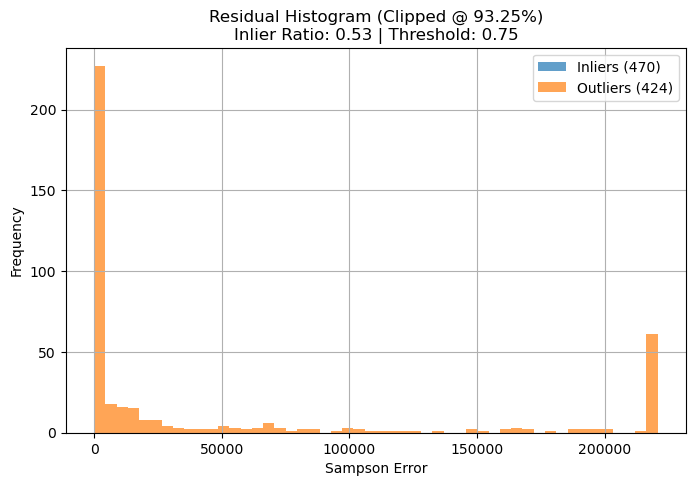


=== Residual Statistics ===
All Points: {'mean': 73160.75323190981, 'median': 0.6256205881719699, 'std': 299582.90247405553, 'min': 2.1605718090678382e-08, 'max': 2887470.809154761}
Inliers   : {'mean': 0.18438379115562303, 'median': 0.09534248648384924, 'std': 0.2039623627336535, 'min': 2.1605718090678382e-08, 'max': 0.7345087069323764}
Outliers  : {'mean': 154258.55360600364, 'median': 2187.979796888175, 'std': 420388.90994628356, 'min': 0.7510600984162253, 'max': 2887470.809154761}


In [180]:
# --- Assume you already have ---
# F, pts1, pts2
# threshold = 0.75   # your chosen threshold


# Step 1: Compute Sampson error
def compute_sampson_errors(F, pts1, pts2):
    pts1_h = np.hstack([pts1, np.ones((pts1.shape[0], 1))])
    pts2_h = np.hstack([pts2, np.ones((pts2.shape[0], 1))])

    Fx1 = F @ pts1_h.T
    Ftx2 = F.T @ pts2_h.T

    numerator = np.sum(pts2_h * (F @ pts1_h.T).T, axis=1) ** 2
    denom = Fx1[0]**2 + Fx1[1]**2 + Ftx2[0]**2 + Ftx2[1]**2

    errors = numerator / (denom + 1e-12)
    return errors


# --- Compute errors ---
errors = compute_sampson_errors(F, pts1, pts2)

# --- Step 2: Define inliers based on threshold ---
threshold = 0.75
inliers = errors < threshold

print("Total matches:", len(errors))
print("Inliers:", np.sum(inliers))
print("Outliers:", np.sum(~inliers))


# --- Step 3: Plot histogram (robust version) ---
results = plot_residual_histogram_robust(
    F,
    pts1,
    pts2,
    inliers,
    threshold=threshold,
    clip_percentile=93.25,
    log_scale=False,
    save_path="residual_histogram.png"
)

Saved zoomed inlier histogram


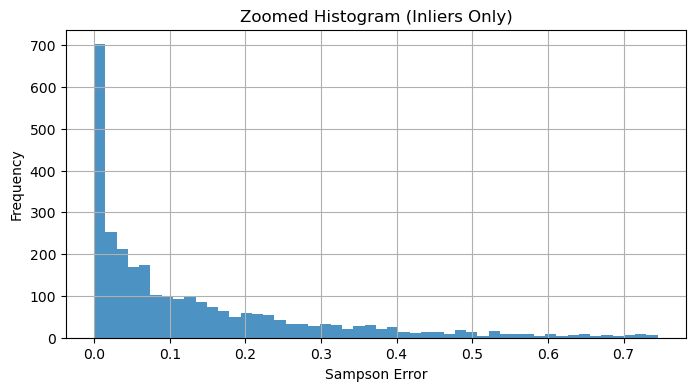

In [142]:
# --- Step 4: Inlier-only zoom plot ---
inlier_errors = errors[inliers]

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(inlier_errors, bins=50, alpha=0.8)
plt.title("Zoomed Histogram (Inliers Only)")
plt.xlabel("Sampson Error")
plt.ylabel("Frequency")
plt.grid()

plt.savefig("../Report/inlier_zoom_histogram.png", dpi=300, bbox_inches='tight')
print("Saved zoomed inlier histogram")

plt.show()

Saved histogram to: ../Report/residual_histogram.png


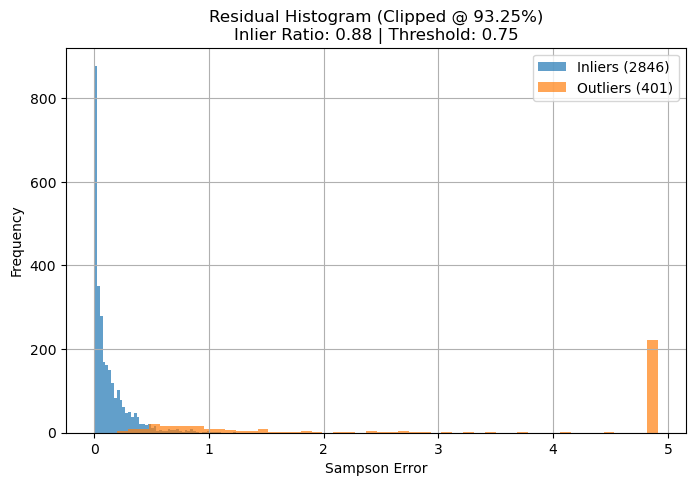


=== Residual Statistics ===
All Points: {'mean': 2319.378035734474, 'median': 0.09132032389137303, 'std': 28180.774133061346, 'min': 5.748761834311643e-08, 'max': 615884.8197146634}
Inliers   : {'mean': 0.12996779681670323, 'median': 0.06737799561954542, 'std': 0.1661928950608255, 'min': 5.748761834311643e-08, 'max': 1.2326783289506118}
Outliers  : {'mean': 18779.677290972813, 'median': 13.316810755174815, 'std': 78239.17431243806, 'min': 0.20002070549298237, 'max': 615884.8197146634}


In [138]:
image_dir = "../Report"
results = plot_residual_histogram_robust(
    F,
    pts1,
    pts2,
    inliers,
    threshold=0.75,
    clip_percentile=93.25,
    log_scale=False,
    save_path= os.path.join(image_dir,"residual_histogram.png")
)

## Visualizing Epipolar Line (and Epipole)

In [224]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


# --- Compute epipoles ---
def compute_epipoles(F):
    U, S, Vt = np.linalg.svd(F)
    e1 = Vt[-1]
    e1 = e1 / e1[2]

    U, S, Vt = np.linalg.svd(F.T)
    e2 = Vt[-1]
    e2 = e2 / e2[2]

    return e1, e2


# --- Check if epipole inside image ---
def is_inside(epipole, width, height):
    x, y = epipole[0], epipole[1]
    return (0 <= x <= width) and (0 <= y <= height)


def draw_epipolar_lines_clean(img1, img2, pts1, pts2, F, num_points=20):
    h, w = img1.shape[:2]

    img1_vis = img1.copy()
    img2_vis = img2.copy()

    idx = np.random.choice(len(pts1), min(num_points, len(pts1)), replace=False)

    pts1_sample = pts1[idx]
    pts2_sample = pts2[idx]

    pts1_h = np.hstack([pts1_sample, np.ones((len(pts1_sample), 1))])
    pts2_h = np.hstack([pts2_sample, np.ones((len(pts2_sample), 1))])

    lines2 = (F @ pts1_h.T).T
    lines1 = (F.T @ pts2_h.T).T

    colors = np.random.rand(len(pts1_sample), 3)
    BRIGHT_COLORS = [
    (255, 0, 0),     # Red
    (0, 255, 0),     # Green
    (0, 0, 255),     # Blue
    (255, 255, 0),   # Yellow
    (255, 0, 255)]   # Magenta]

    # Draw on image2
    for i, (r, pt) in enumerate(zip(lines2, pts2_sample)):
        color_rgb = BRIGHT_COLORS[i % len(BRIGHT_COLORS)]
        a, b, c = r
        # color_rgb = tuple((color * 255).astype(int).tolist())

        if abs(b) > 1e-6:
            x0, y0 = 0, int(-c / b)
            x1, y1 = w, int(-(c + a * w) / b)
        else:
            x0 = int(-c / a)
            x1 = x0
            y0, y1 = 0, h

        cv2.line(img2_vis, (x0, y0), (x1, y1), color_rgb, 4)

        # --- Highlight point (white halo + colored center) ---
        center = tuple(pt.astype(int))
        cv2.circle(img2_vis, center, 12, (255, 255, 255), -1)  # white background
        cv2.circle(img2_vis, center, 8, color_rgb, -1)        # colored point

    # Draw on image1
    for i, (r, pt) in enumerate(zip(lines1, pts1_sample)):
        color_rgb = BRIGHT_COLORS[i % len(BRIGHT_COLORS)]
        a, b, c = r
        # color_rgb = tuple((color * 255).astype(int).tolist())

        if abs(b) > 1e-6:
            x0, y0 = 0, int(-c / b)
            x1, y1 = w, int(-(c + a * w) / b)
        else:
            x0 = int(-c / a)
            x1 = x0
            y0, y1 = 0, h

        cv2.line(img1_vis, (x0, y0), (x1, y1), color_rgb, 4)

        center = tuple(pt.astype(int))
        cv2.circle(img1_vis, center, 12, (255, 255, 255), -1)
        cv2.circle(img1_vis, center, 8, color_rgb, -1)

    return img1_vis, img2_vis


# --- Main Visualization ---
def visualize_epipolar_clean(img1, img2, pts1, pts2, F,
                            num_points=20,
                            save_path=None):

    h, w = img1.shape[:2]

    e1, e2 = compute_epipoles(F)

    inside1 = is_inside(e1, w, h)
    inside2 = is_inside(e2, w, h)

    img1_vis, img2_vis = draw_epipolar_lines_clean(
        img1, img2, pts1, pts2, F, num_points=num_points
    )

    img1_vis = cv2.cvtColor(img1_vis, cv2.COLOR_BGR2RGB)
    img2_vis = cv2.cvtColor(img2_vis, cv2.COLOR_BGR2RGB)

    # --- Compact plot ---
    fig, axes = plt.subplots(1, 2, figsize=(8, 7))

    axes[0].imshow(img1_vis)
    axes[0].set_title("Image 1")
    axes[0].axis("off")

    axes[1].imshow(img2_vis)
    axes[1].set_title("Image 2")
    axes[1].axis("off")

    # Reduce gap
    plt.subplots_adjust(wspace=0.02, top=0.88)

    # --- Epipole info at TOP ---
    info_text = (
        f"Image Size: [{w}, {h}]\n"
        f"Epipole1: ({e1[0]:.1f}, {e1[1]:.1f}) → {'Outside' if not inside1 else 'Inside'}\n "
        f"Epipole2: ({e2[0]:.1f}, {e2[1]:.1f}) → {'Outside' if not inside2 else 'Inside'}"
    )

    plt.figtext(
        0.5, 0.95, info_text,
        ha="center", fontsize=11,
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
    )

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved improved epipolar visualization to: {save_path}")

    plt.show()

Saved improved epipolar visualization to: epipolar_clean.png


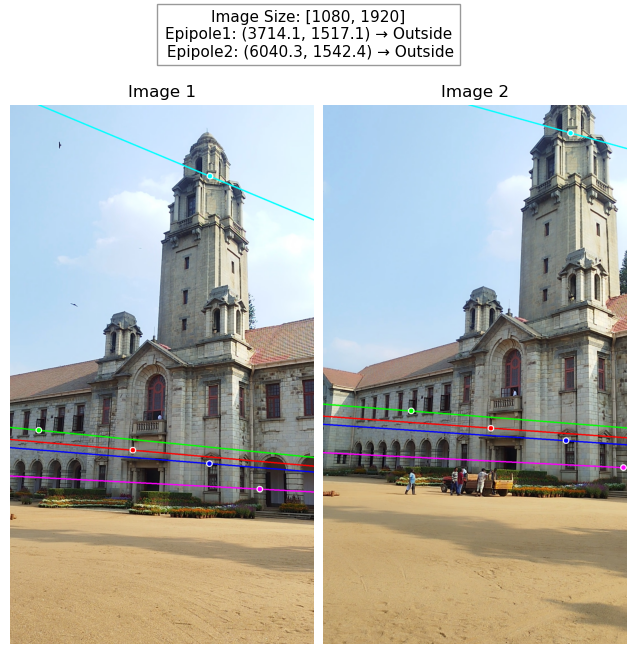

In [179]:
visualize_epipolar_clean( img1, img2, pts1, pts2, F, num_points=5, save_path="epipolar_clean.png")

## Baseline vs Errors

In [230]:
# Overall Driver Code
def driver_function(df_pairs, df_images, image_indexes):
    
    # For the given pairs, run the overall Code
    for index in image_indexes:

        ######### FEATURE EXTRACTION AND MATCHING #########
        
        print("#"*20, "  FEATURE EXTRACTION AND MATCHING  ", "#"*20)
        # Image Path and ID
        id1 = image_id_pairs[index][0]
        id2 = image_id_pairs[index][1]
        img1_path = image_pairs[index][0]
        img2_path = image_pairs[index][1]
        
        # 1. Load images
        img1, img2 = load_images(img1_path, img2_path)
        
        # 2. SIFT features
        kp1, des1, kp2, des2 = compute_sift_features(img1, img2)
        
        print(f"Keypoints Image1: {len(kp1)}")
        print(f"Keypoints Image2: {len(kp2)}")
        
        # 3. Matching
        matches = match_features(des1, des2)
        
        print(f"Good matches (after ratio test): {len(matches)}")
        
        # 4. Extract matched points
        pts1, pts2 = get_matched_points(kp1, kp2, matches)
        
        # 5. Visualization
        visualize_matches_spatial(img1, img2, kp1, kp2, matches, max_matches= 75,grid_size=(6, 8),
            save_path=f"../Report/sift_matches_{index}.png")


        ######### FUNDAMENTAL MATRIX EVALUATION #########
        print()
        print("#"*20, "  FUNDAMENTAL MATRIX EVALUATION  ", "#"*20)
        F, inliers = ransac_fundamental(pts1, pts2, num_iters = 2500,threshold = .75)

        print("Estimated Fundamental Matrix:\n", F)
        print("\nNumber of Inliers:", np.sum(inliers))
        
        # Sanity Checks
        print("\nRank of the Fundamental Matrix: ",np.linalg.matrix_rank(F))  # Rank should be 2
        print(f"Det of the Fundamental Matrix: {abs(np.linalg.det(F)):.6f}")  # Determinant ~ 0


        ######### RESIDUAL ERROR HISTOGRAM PLOT #########

        # --- Compute errors ---
        errors = compute_sampson_errors(F, pts1, pts2)
        
        # --- Step 2: Define inliers based on threshold ---
        threshold = 0.75
        inliers = errors < threshold
        
        print("Total matches:", len(errors))
        print("Inliers:", np.sum(inliers))
        print("Outliers:", np.sum(~inliers))
        
        
        # --- Step 3: Plot histogram (robust version) ---
        results = plot_residual_histogram_robust(F, pts1, pts2,
            inliers, threshold=threshold, clip_percentile=93.25,
            log_scale=False,save_path=f"../Report/residual_histogram_{index}.png")

        ######### EPIPOLAR LINES PLOT #########
        visualize_epipolar_clean( img1, img2, pts1, pts2, F, num_points=5, save_path=f"../Report/epipolar_lines_{index}.png")

        ######### ESSENTIAL MATRIX EVALUATION #########
        print()
        print("#"*20, "  ESSENTIAL MATRIX AND ERRORS  ", "#"*20)
        process_pair(F, pts1, pts2, df_images,id1, id2)

In [222]:
import pandas as pd
import numpy as np


def driver_function(df_pairs, df_images, image_id_pairs, image_pairs,image_indexes):

    all_results = []

    for index in image_indexes:

        print("\n" + "="*60)
        print(f"Processing Pair Index: {index}")
        print("="*60)

        ######### FEATURE EXTRACTION #########
        
        id1 = image_id_pairs[index][0]
        id2 = image_id_pairs[index][1]
        img1_path = image_pairs[index][0]
        img2_path = image_pairs[index][1]

        img1, img2 = load_images(img1_path, img2_path)

        kp1, des1, kp2, des2 = compute_sift_features(img1, img2)

        matches = match_features(des1, des2)
        pts1, pts2 = get_matched_points(kp1, kp2, matches)

        visualize_matches_spatial(
            img1, img2, kp1, kp2, matches,
            max_matches=75,
            grid_size=(6, 8),
            save_path=f"../Report/sift_matches_{index}.png"
        )

        ######### FUNDAMENTAL MATRIX #########
        F, inliers = ransac_fundamental(
            pts1, pts2,
            num_iters=2500,
            threshold=0.75
        )

        errors = sampson_error(F, pts1, pts2)
        inliers = errors < 0.75

        num_matches = len(matches)
        num_inliers = np.sum(inliers)
        inlier_ratio = num_inliers / num_matches

        ######### HISTOGRAM #########
        plot_residual_histogram_robust(
            F, pts1, pts2,
            inliers,
            threshold=0.75,
            clip_percentile=93.25,
            save_path=f"../Report/residual_histogram_{index}.png"
        )

        ######### EPIPOLAR #########
        visualize_epipolar_clean(
            img1, img2, pts1, pts2, F,
            num_points=5,
            save_path=f"../Report/epipolar_lines_{index}.png"
        )

        ######### ESSENTIAL MATRIX + ERRORS #########

        # This function MUST return values now
        R_est, t_est, R_gt, t_gt, baseline = process_pair(
            F, pts1, pts2, df_images, id1, id2
        )

        rot_err = rotation_error(R_est, R_gt)
        trans_err = translation_error(t_est, t_gt)

        ######### STORE RESULTS #########

        result = {
            "pair_index": index,
            "image1_id": id1,
            "image2_id": id2,
            "num_matches": num_matches,
            "num_inliers": num_inliers,
            "inlier_ratio": inlier_ratio,
            "baseline": baseline,
            "rotation_error": rot_err,
            "translation_error": trans_err
        }

        all_results.append(result)

    # Convert to DataFrame
    results_df = pd.DataFrame(all_results)

    # Save
    results_df.to_csv("../Report/final_results.csv", index=False)
    print("\nSaved results to ../Report/final_results.csv")

    return results_df

In [206]:
df_pairs = pd.read_csv("../best_image_pairs3.csv")
df_analysis = df_pairs.iloc[[1,2,7,36,23,65,63],:].copy().reset_index()

image_base_path = "/Users/arjunmallick/Reconstruction_Projects/Main-Building-Dense-2/Images"
image_pairs = []
image_id_pairs = []

print("#"*15," Best Image Pairs ","#"*15)
for idx, row in df_analysis.iterrows():
        i = row["img1_id"]
        j = row["img2_id"]

        img1_row = df_images[df_images.image_id == i].iloc[0]
        img2_row = df_images[df_images.image_id == j].iloc[0]

        # print(f"{img1_row.image_name} ↔ {img2_row.image_name}")

        path1 = os.path.join(image_base_path,img1_row.image_name)
        path2 = os.path.join(image_base_path,img2_row.image_name)

        image_pairs.append((path1, path2))
        image_id_pairs.append((int(i),int(j)))

print(df_analysis)

###############  Best Image Pairs  ###############
   index  img1_id  img2_id  overlap  baseline      angle     score
0      1      225      232     3793  0.843088   5.652869  0.638692
1      2      226      232     3219  0.840993  13.759098  0.631209
2      7       97       98     2599  0.016004  26.530615       NaN
3     36      113      115     1774  0.033224  35.757935       NaN
4     23        6        7     1471  0.023355  33.386482       NaN
5     65       95      232     1853  1.806992   3.261494       NaN
6     63       33       37     1936  2.279524   3.789288       NaN



Processing Pair Index: 1


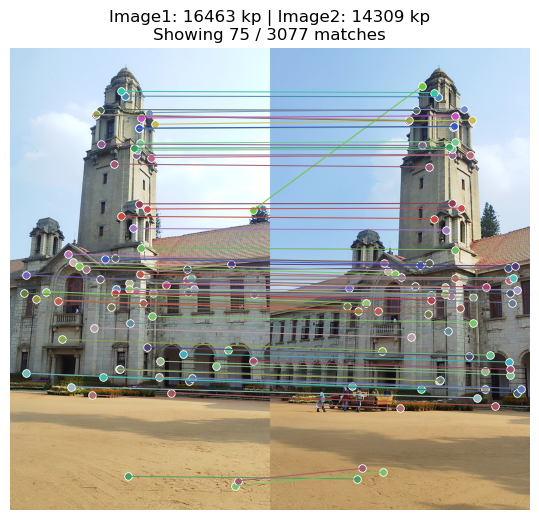

Saved histogram to: ../Report/residual_histogram_1.png


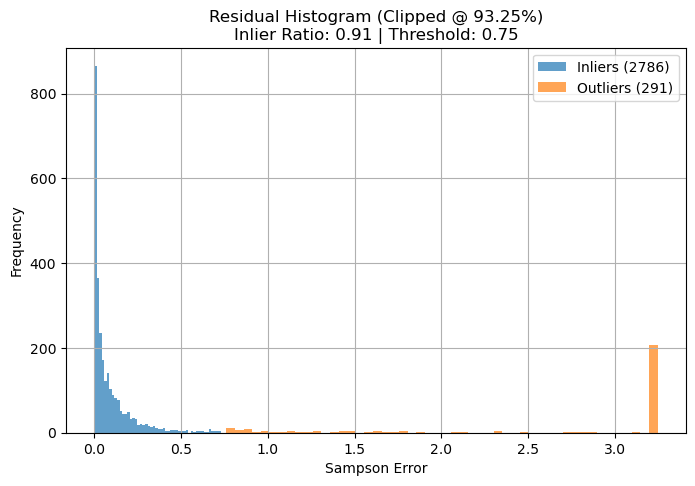


=== Residual Statistics ===
All Points: {'mean': 1483.797221808205, 'median': 0.04981388276074745, 'std': 22220.40226398813, 'min': 9.189576767385239e-09, 'max': 815930.0695999024}
Inliers   : {'mean': 0.0873298340213024, 'median': 0.0384178297732703, 'std': 0.12131063929331677, 'min': 9.189576767385239e-09, 'max': 0.7326380112024948}
Outliers  : {'mean': 15688.662373148672, 'median': 101.31223098301453, 'std': 70696.26120938905, 'min': 0.7615347808054872, 'max': 815930.0695999024}
Saved improved epipolar visualization to: ../Report/epipolar_lines_1.png


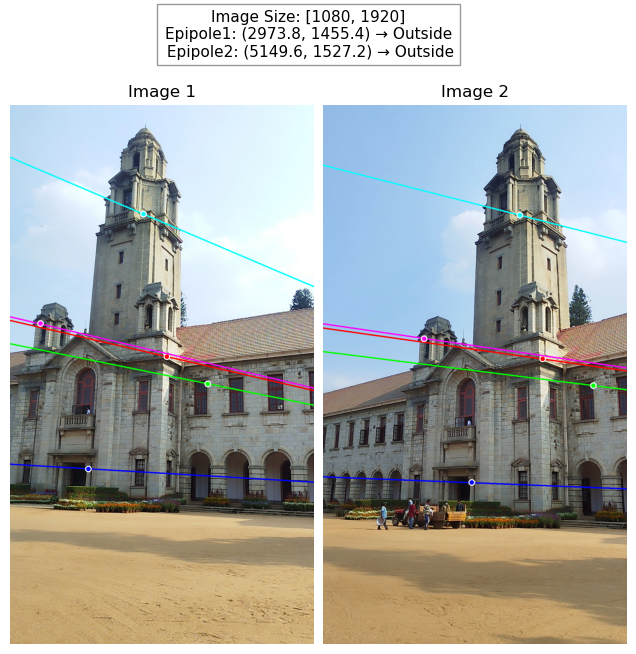

Dot product: -0.9922211726655855

=== Results ===
Estimated Essential Matrix:
 [[-0.00260467  0.31211734 -0.26049726]
 [-0.44573879 -0.0885976   0.84856233]
 [ 0.40628935 -0.86159367  0.02668001]]
Baseline: 0.8410
Rotation Error (deg): 6.048560600922151
Translation Error (deg): 7.151162115901826
Dot product: -0.9922211726655855

Saved results to ../Report/final_results.csv


In [226]:
report_dir = "../Report"
image_indexes= [1]
df_final_results = driver_function(df_analysis, df_images,image_id_pairs, image_pairs, image_indexes)

In [227]:
"""
0---
Rotation Error (deg): 2.7083162067434317
Translation Error (deg): 7.414289979681286

1---
Rotation Error (deg): 6.048560600922151
Translation Error (deg): 7.151162115901826

2---
Rotation Error (deg): 16.804445978640146
Translation Error (deg): 75.26662080724333

3---
Rotation Error (deg): 16.24259595326161
Translation Error (deg): 74.72113594324996

5 ---
Rotation Error (deg): 8.02838908990668
Translation Error (deg): 16.726039763647833

6---
Baseline: 2.2795
Rotation Error (deg): 1.9633971810090456
Translation Error (deg): 38.26647982923146

image1_id	image2_id	num_matches	num_inliers	inlier_ratio	baseline	rotation_error	translation_error


"""
image_id_pairs
df_analysis.to_csv("../best_image_pairs_final.csv", index=False)
# .head(10)

# NEW ANALYSIS

In [86]:
import pandas as pd
import numpy as np


def driver_function_updated(df_pairs, df_images, image_root_path):

    all_results = []

    for idx, row in df_pairs.iterrows():

        id1 = row["img1_id"]
        id2 = row["img2_id"]

        img1_row = df_images[df_images.image_id == id1].iloc[0]
        img2_row = df_images[df_images.image_id == id2].iloc[0]

        print(f"\n\nEvaluating Pair: {id1} ↔ {id2}")
        
        # --- Construct image paths ---
        img1_path = os.path.join(image_base_path,img1_row.image_name)
        img2_path = os.path.join(image_base_path,img2_row.image_name)

        # --- Load images ---
        img1, img2 = load_images(img1_path, img2_path)

        # --- Feature extraction ---
        kp1, des1, kp2, des2 = compute_sift_features(img1, img2)

        # --- Matching ---
        matches = match_features(des1, des2)

        if len(matches) < 8:
            continue  # skip invalid cases

        pts1, pts2 = get_matched_points(kp1, kp2, matches)

        # --- Fundamental matrix ---
        F, inliers = ransac_fundamental(
            pts1, pts2,
            num_iters=2500,
            threshold=0.75
        )

        # --- Sampson error ---
        errors = sampson_error(F, pts1, pts2)
        inliers = errors < 0.75

        num_matches = len(matches)
        num_inliers = np.sum(inliers)
        inlier_ratio = num_inliers / num_matches if num_matches > 0 else 0

        # --- Essential + pose ---
        R_est, t_est, R_gt, t_gt, baseline = process_pair(
            F, pts1, pts2, df_images, id1, id2
        )

        rot_err = rotation_error(R_est, R_gt)
        trans_err = translation_error(t_est, t_gt)

        # --- Store ---
        result = {
            "img1_id": id1,
            "img2_id": id2,
            "num_matches": num_matches,
            "num_inliers": num_inliers,
            "inlier_ratio": inlier_ratio,
            "baseline_est": baseline,
            "rotation_error": rot_err,
            "translation_error": trans_err
        }

        all_results.append(result)

    results_df = pd.DataFrame(all_results)

    # --- Merge with original dataframe ---
    final_df = df_pairs.merge(
        results_df,
        on=["img1_id", "img2_id"],
        how="left"
    )

    return final_df

In [95]:
df_pure_translation = df_pairs[df_pairs["case_type"] == "pure_translation"].copy().sort_values(by = "overlap", ascending = False)
df_pure_rotation = df_pairs[df_pairs["case_type"] == "pure_rotation"][:20]

In [98]:
df_pure_rotation.head()

,img1_id,img2_id,overlap,baseline,angle,score,case_type
6,166,169,614,0.002969,23.969605,NaN,pure_rotation
7,166,168,781,0.003567,17.001848,NaN,pure_rotation
8,86,87,332,0.003581,27.908232,NaN,pure_rotation
9,138,140,315,0.004281,10.326614,NaN,pure_rotation
10,162,163,606,0.006978,13.378862,NaN,pure_rotation


In [125]:
df_pure_translation = df_pairs[df_pairs.img1_id == 96]
image_base_path = "/Users/arjunmallick/Reconstruction_Projects/Main-Building-Dense-2/Images"

df_pure_translation_errors = driver_function_updated(df_pure_translation, df_images, image_base_path)



Evaluating Pair: 96.0 ↔ 233.0
Dot product: 0.9710481386127952

=== Results ===
Estimated Essential Matrix:
 [[ 0.07124424 -0.38865914  0.37884216]
 [ 0.55687058  0.08505392  0.7497007 ]
 [-0.31614786 -0.83849005  0.13394687]]
Baseline: 1.8434
Rotation Error (deg): 8.222708697158435
Translation Error (deg): 13.820675967184695
Dot product: 0.9710481386127952


In [ ]:
## Pure Translation Pairs
# (95,232) -- This
# (96,233) --- This
# (44,93)
# 4 ↔ 45
# 128 ↔ 144


## Pure Rotation Pairs
166 ↔ 168


In [152]:
df_pairs[df_pairs.img1_id == 95]

,img1_id,img2_id,overlap,baseline,angle,score
58,95,224,2329,1.428614,4.884135,NaN
59,95,225,2225,1.443199,3.924084,NaN
65,95,232,1853,1.806992,3.261494,NaN
73,95,233,1626,1.808913,2.775850,NaN


,index,img1_id,img2_id,overlap,baseline,angle,score
0,1,225,232,3793,0.843088,5.652869,0.638692
1,2,226,232,3219,0.840993,13.759098,0.631209
2,7,97,98,2599,0.016004,26.530615,NaN
3,36,113,115,1774,0.033224,35.757935,NaN
4,23,6,7,1471,0.023355,33.386482,NaN
5,65,95,232,1853,1.806992,3.261494,NaN
6,63,33,37,1936,2.279524,3.789288,NaN
